In [1]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

In [ ]:
#Load the tables from prostgreSQL data base
user = 'postgres'
password = 'sql2026'
host = 'localhost'
port = '5432'
database = 'churn_analysis'

#connect with the data base
engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}")

#Queries
#Load the account_info table
query_1 = "SELECT * FROM account_info"
account_info = pd.read_sql(query_1, engine)

#Load the customer_support table
query_2 = "SELECT * FROM customer_support"
customer_support = pd.read_sql(query_2, engine)

#Load user_activity table
query_3 = "SELECT * FROM user_activity"
user_activity = pd.read_sql(query_3, engine)

In [ ]:
#View of account_info df
account_info.head()

,user_id,email,state,plan,plan_list_price,churn_status
0,10000,user10000@example.com,New Jersey,Enterprise,105,Yes
1,10001,user10001@example.net,Louisiana,Basic,22,Yes
2,10002,user10002@example.net,Oklahoma,Basic,24,No
3,10003,user10003@example.com,Michigan,Free,0,No
4,10004,user10004@example.com,Texas,Enterprise,119,No


In [ ]:
#View of customer_suport df
customer_support.head()

,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments,state_label
0,2025-06-13 05:55:17.154573,10125,chat,technical,11.48,1,unknown,Solved
1,2025-08-06 13:21:54.539551,10109,chat,account,1.01,0,unknown,Open
2,2025-08-22 12:39:35.718663,10149,chat,technical,10.09,0,Erase my data from your systems.,Open
3,2025-06-07 02:49:46.986055,10268,phone,account,9.10,1,unknown,Solved
4,2025-07-25 00:24:38.945079,10041,phone,other,2.28,1,unknown,Solved


In [5]:
#View of user_activity df
user_activity.head()

,event_time,user_id,event_type
0,2025-09-08 15:05:39.422721,10118,watch video
1,2025-09-08 08:15:05.264103,10220,watch video
2,2025-11-14 06:28:35.207671,10009,share workout
3,2025-08-20 16:53:38.682901,10227,read article
4,2025-07-24 16:47:31.728422,10123,track workout


### UNIVARIATE ANALYSIS

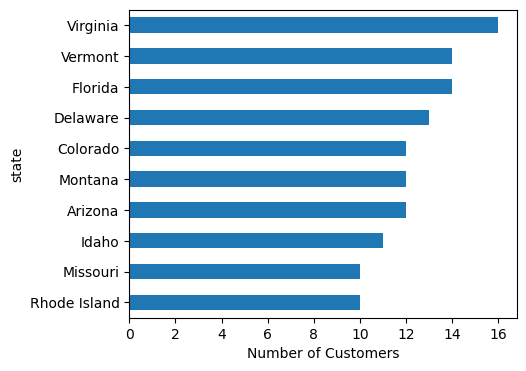

In [12]:
#Top 10 states by number of customers
top_states = account_info['state'].value_counts()
top_states = top_states.head(10).sort_values(ascending = True)
#print(top_states)

#Bar graph
plt.figure(figsize=(5, 4))
top_states.plot(kind='barh')
plt.xlabel('Number of Customers')
plt.show()

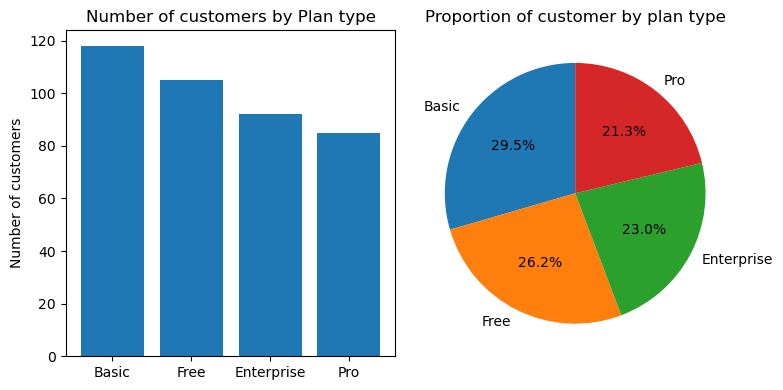

In [22]:
#Number of customers by plan type
num_plan = account_info['plan'].value_counts()
num_plan.sort_values(ascending=False, inplace= True)
#Layout
fig, ax = plt.subplots(1, 2, figsize = (8, 4))
#Bar chart
ax[0].bar(x = num_plan.index, height = num_plan.values)
ax[0].set_title('Number of customers by Plan type')
ax[0].set_ylabel('Number of customers')

#Pie chart
ax[1].pie(x = num_plan.values, labels = num_plan.index, autopct = '%1.1f%%', startangle = 90)
ax[1].set_title('Proportion of customer by plan type')
#show
plt.tight_layout()
plt.show()



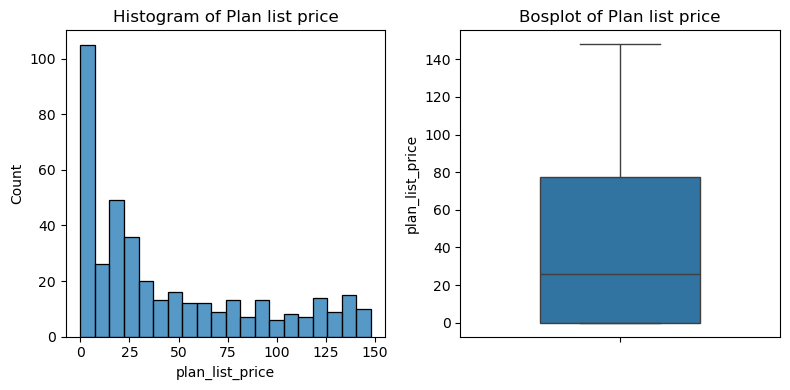

In [30]:
#Distribution of plan list price
#Layout
fig1, ax1 = plt.subplots(1, 2, figsize = (8, 4))

#Histogram
sns.histplot(data = account_info, x = 'plan_list_price', ax = ax1[0], bins = 20)
ax1[0].set_title('Histogram of Plan list price')

#Boxplot
sns.boxplot(data = account_info, y = 'plan_list_price', ax = ax1[1], width = 0.5)
ax1[1].set_title('Bosplot of Plan list price')

#Show
plt.tight_layout()
plt.show()


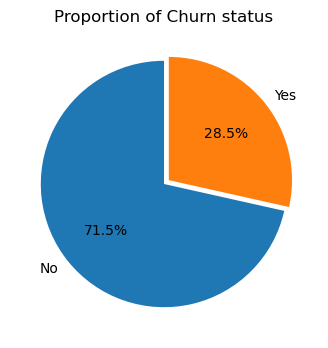

In [36]:
#Proportion of churn status
num_churn = account_info['churn_status'].value_counts()

#pie chart
plt.figure(figsize=(4, 4))
plt.pie(x = num_churn.values, labels = num_churn.index, autopct = "%1.1f%%", startangle = 90, explode = (0, 0.05))
plt.title('Proportion of Churn status')
plt.show()

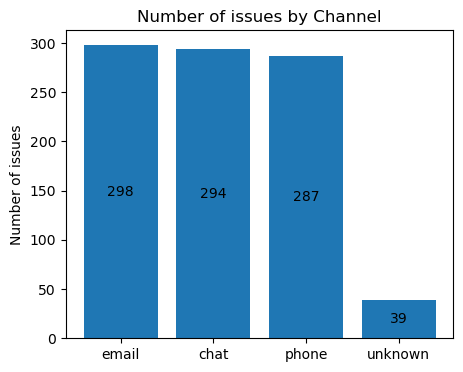

In [43]:
#Number of issues reported by channel
num_channel = customer_support['channel'].value_counts().sort_values(ascending= False)

#Bar chart
plt.figure(figsize=(5, 4))
g = plt.bar(x = num_channel.index, height=  num_channel.values)
plt.title('Number of issues by Channel')
plt.ylabel('Number of issues')
plt.bar_label(g, label_type='center')
plt.show()

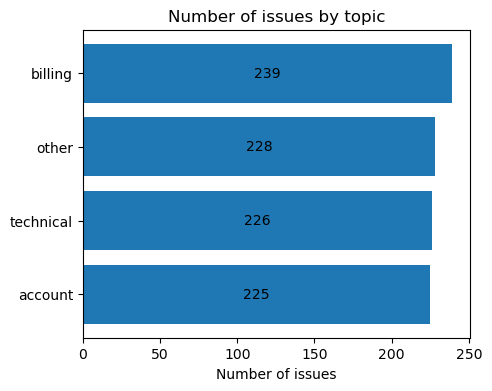

In [48]:
#Number of issues by topic
num_topic = customer_support['topic'].value_counts().sort_values(ascending= True)

#Bar chart
plt.figure(figsize = (5, 4))
g1 = plt.barh(y = num_topic.index, width = num_topic.values)
plt.title('Number of issues by topic')
plt.xlabel('Number of issues')
plt.bar_label(g1, label_type='center')
plt.show()

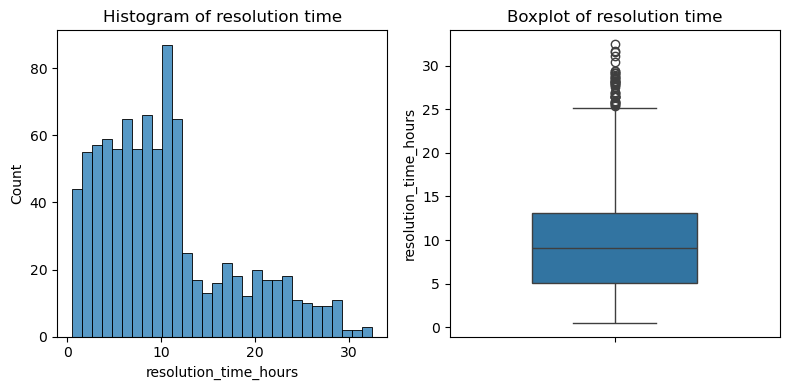

In [57]:
#Distribution of resolution time hours
#layout configuration
fig2, ax2 = plt.subplots(1, 2, figsize = (8, 4))

#Histogram
sns.histplot(data = customer_support, x = 'resolution_time_hours', ax = ax2[0], bins = 30)
ax2[0].set_title('Histogram of resolution time')

#Boxplot
sns.boxplot(data= customer_support, y = 'resolution_time_hours', ax = ax2[1], width=0.5)
ax2[1].set_title('Boxplot of resolution time')
#Show
plt.tight_layout()
plt.show()

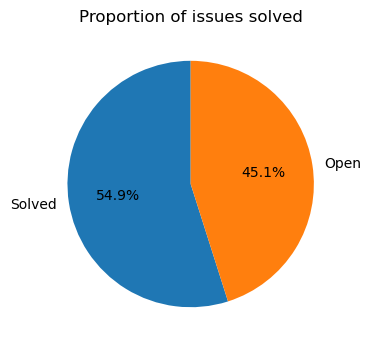

In [61]:
#Proportion of issues solved
num_issue = customer_support['state_label'].value_counts()

#pie chart
plt.figure(figsize=(4, 4))
plt.pie(x = num_issue.values, labels = num_issue.index, startangle = 90, autopct = '%1.1f%%')
plt.title('Proportion of issues solved')
plt.show()

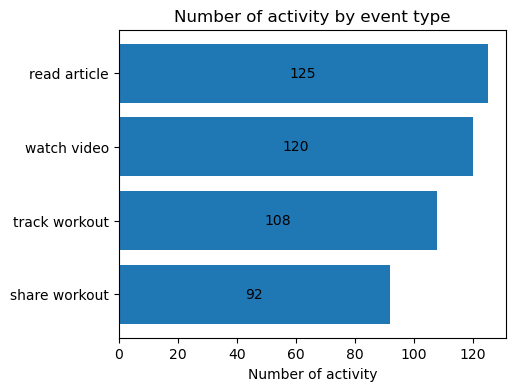

In [64]:
#Number of activity by event type
num_event = user_activity['event_type'].value_counts().sort_values(ascending=True)

#Bar chart
plt.figure(figsize=(5, 4))
g3 = plt.barh(y = num_event.index, width = num_event.values)
plt.bar_label(g3, label_type='center')
plt.title('Number of activity by event type')
plt.xlabel('Number of activity')
plt.show()

### BINARY ANALYSIS